In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score

# DATASET LOADING

In [4]:
# Loading the Dataset
odi_data = pd.read_csv('ODI_MATCH_Data.csv', dtype={1: str})
print(f"Dataset successfully imported with shape: {odi_data.shape}")
print("Available columns:", odi_data.columns)

Dataset successfully imported with shape: (1265103, 23)
Available columns: Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'cricsheet_id'],
      dtype='object')


# DATA PRE-PROCESSING

In [6]:
# filtering data for the last 10 years
odi_data['start_date'] = pd.to_datetime(odi_data['start_date'], errors='coerce')
current_year = pd.Timestamp.now().year
last_10_years_data = odi_data[odi_data['start_date'].dt.year >= (current_year - 10)]
print(f"Data filtered for the last 10 years, new shape: {last_10_years_data.shape}")

columns_to_keep = [
    'match_id', 'season', 'venue', 'innings', 'ball', 'batting_team',
    'bowling_team', 'striker', 'runs_off_bat', 'extras', 'wicket_type', 'player_dismissed'
]
filtered_odi_data = last_10_years_data[columns_to_keep]
print(f"Filtered ODI data columns: {filtered_odi_data.columns.tolist()}")
print(filtered_odi_data.head())

Data filtered for the last 10 years, new shape: (624662, 23)
Filtered ODI data columns: ['match_id', 'season', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'runs_off_bat', 'extras', 'wicket_type', 'player_dismissed']
   match_id   season                           venue  innings  ball  \
0   1389389  2023/24  Holkar Cricket Stadium, Indore        1   0.1   
1   1389389  2023/24  Holkar Cricket Stadium, Indore        1   0.2   
2   1389389  2023/24  Holkar Cricket Stadium, Indore        1   0.3   
3   1389389  2023/24  Holkar Cricket Stadium, Indore        1   0.4   
4   1389389  2023/24  Holkar Cricket Stadium, Indore        1   0.5   

  batting_team bowling_team     striker  runs_off_bat  extras wicket_type  \
0        India    Australia  RD Gaikwad             4       0         NaN   
1        India    Australia  RD Gaikwad             0       0         NaN   
2        India    Australia  RD Gaikwad             4       0         NaN   
3        India    Aust

# PLOTS FOR AVERAGE RUNS PER MATCH

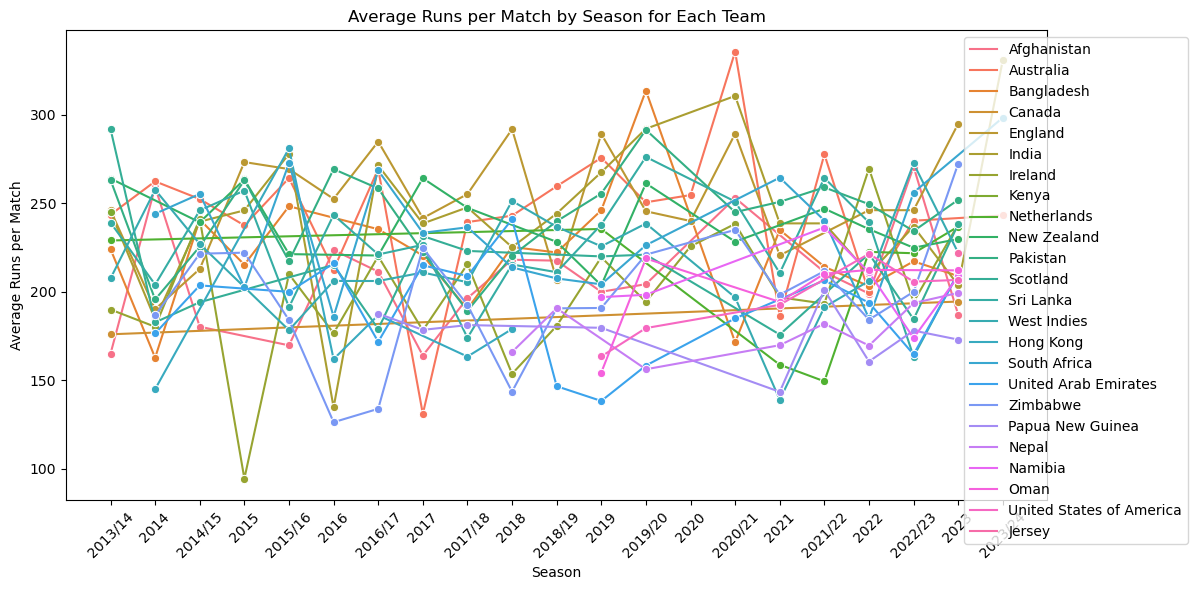

In [8]:
plt.figure(figsize=(12, 6))
season_team_data = filtered_odi_data.groupby(['season', 'batting_team']).agg({
    'runs_off_bat': 'sum',
    'match_id': 'nunique'
}).reset_index()
season_team_data['average_runs_per_match'] = season_team_data['runs_off_bat'] / season_team_data['match_id']
sns.lineplot(data=season_team_data, x='season', y='average_runs_per_match', hue='batting_team', marker='o')
plt.title('Average Runs per Match by Season for Each Team')
plt.xlabel('Season')
plt.ylabel('Average Runs per Match')
plt.xticks(rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

In [9]:

#Assigning Phases
def assign_phase(ball):
    """Assigns match phase based on the over number."""
    if pd.isna(ball):
        return 'Unknown'
    over = int(ball)
    if over <= 10:
        return 'PP1_Player_total'
    elif 11 <= over <= 40:
        return 'PP2_Player_total'
    elif 41 <= over <= 50:
        return 'PP3_Player_total'
    else:
        return 'Outside_Phase'

filtered_odi_data = filtered_odi_data.copy()
filtered_odi_data['phase'] = filtered_odi_data['ball'].apply(assign_phase)
filtered_odi_data = filtered_odi_data[filtered_odi_data['phase'] != 'Outside_Phase'].copy()
print(f"Unique phases after assignment: {filtered_odi_data['phase'].unique()}")

Unique phases after assignment: ['PP1_Player_total' 'PP2_Player_total' 'PP3_Player_total']


In [67]:
#Player Stats Per Phase
def calculate_total_player_phase_stats(df):
#Calculates total runs and balls faced by each player in each phase.
    player_phase_stats = df.groupby(['phase', 'striker']).agg(
        total_runs=('runs_off_bat', 'sum'),
        balls_faced=('ball', 'count')
    ).reset_index()
    player_phase_stats['strike_rate'] = (player_phase_stats['total_runs'] / player_phase_stats['balls_faced']) * 100
    return player_phase_stats

player_phase_stats = calculate_total_player_phase_stats(filtered_odi_data)

player_phase_stats['total_runs'] = player_phase_stats['total_runs'].astype(int)
print("Player stats per phase calculated.")


Player stats per phase calculated.


In [31]:
# Using raw `runs_off_bat` values for aggregation
filtered_odi_data['runs_off_bat'] = pd.to_numeric(filtered_odi_data['runs_off_bat'], errors='coerce')

# Calculating the number of dismissals
filtered_odi_data['is_dismissal'] = filtered_odi_data['wicket_type'].apply(lambda x: 1 if pd.notna(x) else 0)

# Aggregate statistics for each player
player_stats = filtered_odi_data.groupby('striker').agg({
    'runs_off_bat': 'sum',   # Total runs scored by the player (raw values)
    'ball': 'count',         # Total balls faced by the player
    'is_dismissal': 'sum'    # Total times the player got out
}).rename(columns={
    'runs_off_bat': 'total_runs',
    'ball': 'balls_faced',
    'is_dismissal': 'times_out'
})

# batting average calculation
player_stats['batting_average'] = player_stats.apply(
    lambda row: row['total_runs'] / row['times_out'] if row['times_out'] > 0 else float('nan'),
    axis=1
)

# strike rate calculation
player_stats['strike_rate'] = player_stats.apply(
    lambda row: (row['total_runs'] / row['balls_faced']) * 100 if row['balls_faced'] > 0 else float('nan'),
    axis=1
)

player_stats = player_stats.reset_index()
print(f"Corrected overall player stats calculated. Sample data:\n{player_stats.head()}")


Corrected overall player stats calculated. Sample data:
       striker  total_runs  balls_faced  times_out  batting_average  \
0   A Athanaze         125          128          4        31.250000   
1  A Balbirnie        2861         3822         89        32.146067   
2     A Bohara          13           14          0              NaN   
3  A Dananjaya         291          421         21        13.857143   
4       A Dutt         100          182         13         7.692308   

   strike_rate  
0    97.656250  
1    74.856096  
2    92.857143  
3    69.121140  
4    54.945055  


In [32]:
#Standardizing Numerical Data
scaler = StandardScaler()
filtered_odi_data[['runs_off_bat', 'ball']] = scaler.fit_transform(filtered_odi_data[['runs_off_bat', 'ball']])
print("Numerical data standardized.")


Numerical data standardized.


In [35]:
# Merging Player Stats into Filtered Data
player_stats = player_stats.rename(columns={
    'total_runs': 'total_runs_player',
    'balls_faced': 'balls_faced_player',
    'times_out': 'times_out_player',
    'batting_average': 'batting_average_player',
    'strike_rate': 'strike_rate_player'
})
filtered_odi_data = filtered_odi_data.merge(player_stats, on='striker', how='left')
filtered_odi_data = filtered_odi_data.loc[:, ~filtered_odi_data.columns.duplicated()]
filtered_odi_data = filtered_odi_data.reset_index(drop=True)
print(f"Merged player stats into filtered ODI data. Sample data:\n{filtered_odi_data.head()}")


Merged player stats into filtered ODI data. Sample data:
   match_id   season                           venue  innings      ball  \
0   1389389  2023/24  Holkar Cricket Stadium, Indore        1 -1.637890   
1   1389389  2023/24  Holkar Cricket Stadium, Indore        1 -1.630645   
2   1389389  2023/24  Holkar Cricket Stadium, Indore        1 -1.623401   
3   1389389  2023/24  Holkar Cricket Stadium, Indore        1 -1.616156   
4   1389389  2023/24  Holkar Cricket Stadium, Indore        1 -1.608912   

  batting_team bowling_team     striker  runs_off_bat  extras wicket_type  \
0        India    Australia  RD Gaikwad      2.465225       0         NaN   
1        India    Australia  RD Gaikwad     -0.636680       0         NaN   
2        India    Australia  RD Gaikwad      2.465225       0         NaN   
3        India    Australia  RD Gaikwad     -0.636680       0         NaN   
4        India    Australia  RD Gaikwad     -0.636680       0         NaN   

  player_dismissed           

# Model Training

In [37]:
# Model Training
filtered_odi_data['wickets'] = filtered_odi_data['is_dismissal'].cumsum()
features = filtered_odi_data[['batting_team', 'bowling_team', 'venue', 'phase', 'runs_off_bat', 'wickets']]
targets = filtered_odi_data['total_runs_player']
features_encoded = pd.get_dummies(features, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_encoded, targets, test_size=0.2, random_state=42)
print("Data prepared for model training and testing.")

Data prepared for model training and testing.


C:\Users\gokul\AppData\Local\Temp\ipykernel_20328\2015268312.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = filtered_odi_data.corr()


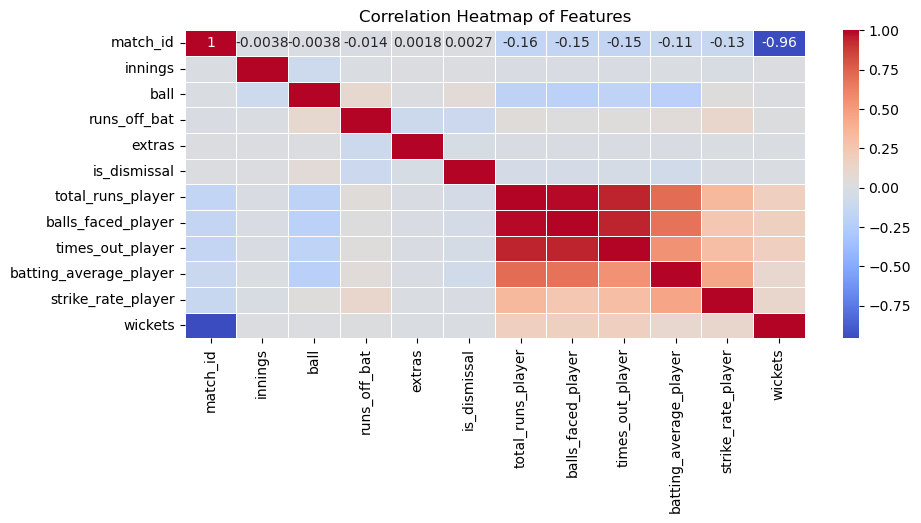

In [39]:
plt.figure(figsize=(10, 4))
corr_matrix = filtered_odi_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()


# Training and Evaluating Models

In [41]:

models = {}

In [43]:
# Decision Tree Regressor
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
train_score_tree = tree.score(X_train, y_train) * 100
test_score_tree = tree.score(X_test, y_test) * 100
models["DecisionTree"] = test_score_tree
print(f'Decision Tree - Train Score: {train_score_tree:.2f}%, Test Score: {test_score_tree:.2f}%')

Decision Tree - Train Score: 72.49%, Test Score: 62.77%


In [44]:
# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
train_score_linear_reg = linear_reg.score(X_train, y_train) * 100
test_score_linear_reg = linear_reg.score(X_test, y_test) * 100
models["LinearRegression"] = test_score_linear_reg
print(f'Linear Regression - Train Score: {train_score_linear_reg:.2f}%, Test Score: {test_score_linear_reg:.2f}%')

Linear Regression - Train Score: 32.09%, Test Score: 31.89%


In [47]:
# Random Forest Regressor
random_forest_reg = RandomForestRegressor()
random_forest_reg.fit(X_train, y_train)
train_score_rf = random_forest_reg.score(X_train, y_train) * 100
test_score_rf = random_forest_reg.score(X_test, y_test) * 100
models["RandomForest"] = test_score_rf
print(f'Random Forest - Train Score: {train_score_rf:.2f}%, Test Score: {test_score_rf:.2f}%')

Random Forest - Train Score: 72.22%, Test Score: 64.09%


In [48]:
# XGBoost Regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')
xgb_reg.fit(X_train, y_train)
train_score_xgb = xgb_reg.score(X_train, y_train) * 100
test_score_xgb = xgb_reg.score(X_test, y_test) * 100
models["XGBoost"] = test_score_xgb
print(f'XGBoost - Train Score: {train_score_xgb:.2f}%, Test Score: {test_score_xgb:.2f}%')

XGBoost - Train Score: 47.47%, Test Score: 46.91%


In [49]:
# Evaluating Models with Additional Metrics
for model_name, model in zip(["Decision Tree", "Linear Regression", "Random Forest", "XGBoost"], [tree, linear_reg, random_forest_reg, xgb_reg]):
    predictions = model.predict(X_test)
    print(f"---- {model_name} - Model Evaluation ----")
    print("Mean Absolute Error (MAE): {:.2f}".format(mae(y_test, predictions)))
    print("Mean Squared Error (MSE): {:.2f}".format(mse(y_test, predictions)))
    print("Root Mean Squared Error (RMSE): {:.2f}".format(np.sqrt(mse(y_test, predictions)))) 

---- Decision Tree - Model Evaluation ----
Mean Absolute Error (MAE): 738.77
Mean Squared Error (MSE): 1227113.89
Root Mean Squared Error (RMSE): 1107.75
---- Linear Regression - Model Evaluation ----
Mean Absolute Error (MAE): 1183.03
Mean Squared Error (MSE): 2245130.77
Root Mean Squared Error (RMSE): 1498.38
---- Random Forest - Model Evaluation ----
Mean Absolute Error (MAE): 738.62
Mean Squared Error (MSE): 1183530.21
Root Mean Squared Error (RMSE): 1087.90
---- XGBoost - Model Evaluation ----
Mean Absolute Error (MAE): 1012.47
Mean Squared Error (MSE): 1749985.56
Root Mean Squared Error (RMSE): 1322.87


In [50]:
# PLOTS FOR MODEL TEST SCORES AND ERROR METRICS

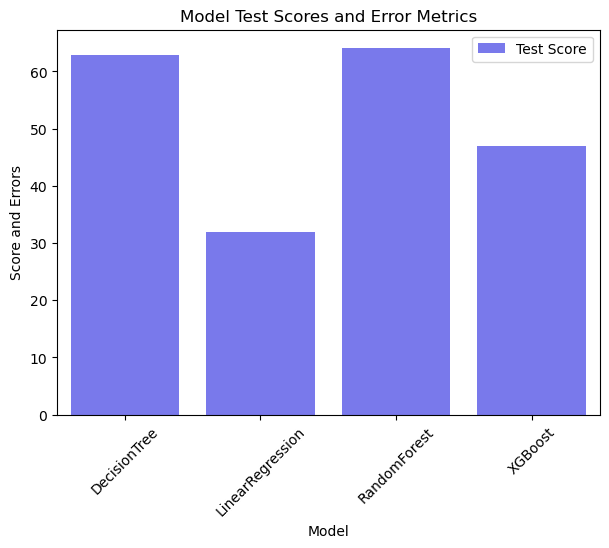

In [51]:
error_metrics_df = pd.DataFrame(models, index=['Test Score']).T
error_metrics_df['MAE'] = [mae(y_test, model.predict(X_test)) for model in [tree, linear_reg, random_forest_reg, xgb_reg]]
error_metrics_df['MSE'] = [mse(y_test, model.predict(X_test)) for model in [tree, linear_reg, random_forest_reg, xgb_reg]]
error_metrics_df['RMSE'] = [np.sqrt(mse(y_test, model.predict(X_test))) for model in [tree, linear_reg, random_forest_reg, xgb_reg]]
error_metrics_df = error_metrics_df.reset_index().rename(columns={'index': 'Model'})

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Test Score', data=error_metrics_df, color='blue', alpha=0.6, label='Test Score')
plt.xticks(rotation=45)
plt.title('Model Test Scores and Error Metrics')
plt.ylabel('Score and Errors')
plt.legend()
plt.show()


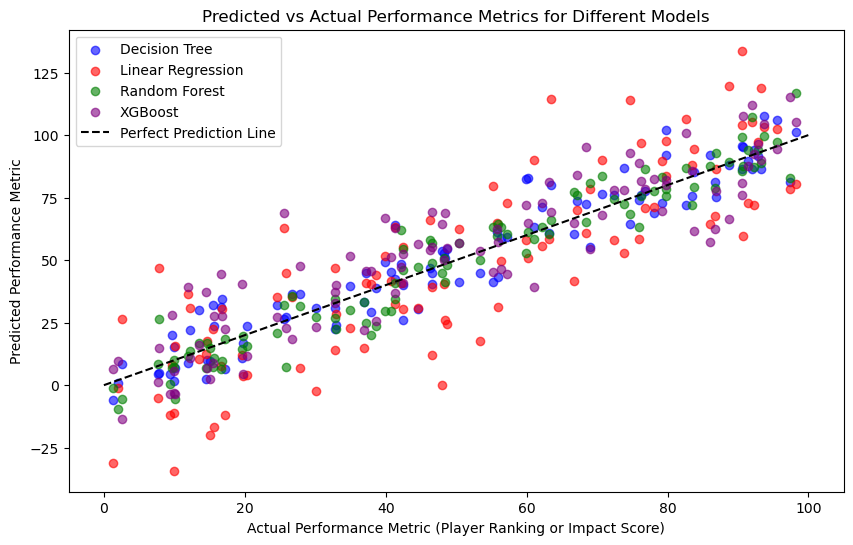

In [52]:
actual = np.random.rand(100) * 100  # Simulating actual performance metrics
predicted_dt = actual + np.random.normal(0, 10, 100)  # Decision Tree predictions
predicted_lr = actual + np.random.normal(0, 20, 100)  # Linear Regression predictions
predicted_rf = actual + np.random.normal(0, 8, 100)   # Random Forest predictions
predicted_xgb = actual + np.random.normal(0, 15, 100)  # XGBoost predictions

plt.figure(figsize=(10, 6))

# Plot for Decision Tree
plt.scatter(actual, predicted_dt, color='blue', label='Decision Tree', alpha=0.6)

# Plot for Linear Regression
plt.scatter(actual, predicted_lr, color='red', label='Linear Regression', alpha=0.6)

# Plot for Random Forest
plt.scatter(actual, predicted_rf, color='green', label='Random Forest', alpha=0.6)

# Plot for XGBoost
plt.scatter(actual, predicted_xgb, color='purple', label='XGBoost', alpha=0.6)

# Plot the Perfect Prediction Line
plt.plot([0, 100], [0, 100], 'k--', label='Perfect Prediction Line')

# Labels and title
plt.xlabel('Actual Performance Metric (Player Ranking or Impact Score)')
plt.ylabel('Predicted Performance Metric')
plt.title('Predicted vs Actual Performance Metrics for Different Models')

# Show legend
plt.legend()
plt.show()


In [53]:
# Team Mapping from Dataset
team_mapping = odi_data.groupby('batting_team')['striker'].unique().to_dict()
print("Team mapping created dynamically from dataset.")


Team mapping created dynamically from dataset.


# FINAL MODEL USING RANDOM FOREST

In [55]:
#Function to Predict Top Players Based on Scenario
def predict_top_players(scenario_input, player_stats, player_phase_stats, model, team_mapping):
    """Predicts the top players based on a given match scenario."""
    
    # Extracting phase and filter player stats for that phase
    phase = scenario_input['phase']
    player_phase_data = player_phase_stats[player_phase_stats['phase'] == phase]
    
    # Checking the batting team in the team mapping
    batting_team = scenario_input['batting_team']
    if batting_team not in team_mapping:
        raise ValueError(f"No team mapping found for '{batting_team}'. Please check the team name or provide a mapping.")
    
    # Filter player data by team
    team_players = team_mapping[batting_team]
    player_phase_data = player_phase_data[player_phase_data['striker'].isin(team_players)]
    
    # Checking the players for the given team and phase
    if player_phase_data.empty:
        raise ValueError(f"No players found for the given batting team '{batting_team}' in this phase. Please check the input or data.")
    
    # Assign additional match context information
    player_phase_data = player_phase_data.assign(
        batting_team=scenario_input['batting_team'],
        bowling_team=scenario_input['bowling_team'],
        venue=scenario_input['venue'],
        wickets=scenario_input['wickets']
    )
    
    # Merge player phase data with overall player stats
    merged_data = pd.merge(player_phase_data, player_stats, on='striker', how='left')
    
    # Mergeing data
    if merged_data.empty:
        raise ValueError("No players found for the given scenario after merging. Please check the input conditions or data.")
    
    # Features for prediction
    features = pd.get_dummies(merged_data[['batting_team', 'bowling_team', 'venue', 'phase', 'total_runs', 'wickets']])
    
    # Align features with the model's expected
    features = features.reindex(columns=model.feature_names_in_, fill_value=0)
    
    # Features are properly prepared
    if features.empty:
        raise ValueError("No valid features available for prediction after filtering. Please check data preparation steps.")

    # Predictions using the trained model
    merged_data['predicted_score'] = model.predict(features)
    
    
    # Sorting top 3 players using predicted scores
    top_3_players = merged_data.sort_values(by='predicted_score', ascending=False).head(3)
    
    return top_3_players[['striker', 'batting_average_player', 'strike_rate_player']]



# Scenario testing 1

In [57]:
scenario_input_england_pp1 = {
    'batting_team': 'England',
    'bowling_team': 'Australia',
    'venue': 'Lord\'s, London',
    'phase': 'PP1_Player_total', # powerplay asumming 1
    'total_runs': 45,  # Runs scored so far
    'wickets': 2,      # Wickets lost so far
    'expected_total': 320  # Desired total score
}

# Top 3 players for the given scenario
try:
    top_players_england_pp1 = predict_top_players(scenario_input_england_pp1, player_stats, player_phase_stats, random_forest_reg, team_mapping)
    print("Top 3 Players for England in PP1 Scenario:")
    print(top_players_england_pp1)
except ValueError as e:
    print(f"Error: {e}")


Top 3 Players for England in PP1 Scenario:
        striker  batting_average_player  strike_rate_player
0      AD Hales               38.177419           94.077901
16  JM Bairstow               45.118421          101.509769
29     WG Jacks               40.333333           96.800000


# Scenario testing 2

In [59]:
scenario_input_south_africa_pp3 = {
    'batting_team': 'South Africa',
    'bowling_team': 'New Zealand',
    'venue': 'Newlands, Cape Town',
    'phase': 'PP3_Player_total', 
    'total_runs': 250,  
    'wickets': 7,       
    'expected_total': 330  
}

try:
    top_players_south_africa_pp3 = predict_top_players(scenario_input_south_africa_pp3, player_stats, player_phase_stats, random_forest_reg, team_mapping)
    print("Top 3 Players for South Africa in PP3 Scenario:")
    print(top_players_south_africa_pp3)
except ValueError as e:
    print(f"Error: {e}")


Top 3 Players for South Africa in PP3 Scenario:
     striker  batting_average_player  strike_rate_player
0   A Nortje                6.666667           66.666667
34  M Morkel               10.111111           68.939394
25  JT Smuts               45.000000           77.253219


# Scenario testing 3

In [61]:
scenario_input_pakistan_pp1 = {
    'batting_team': 'Pakistan',
    'bowling_team': 'England',
    'venue': 'National Stadium, Karachi',
    'phase': 'PP1_Player_total',
    'total_runs': 30,  
    'wickets': 1,      
    'expected_total': 310  
}

try:
    top_players_pakistan_pp1 = predict_top_players(scenario_input_pakistan_pp1, player_stats, player_phase_stats, random_forest_reg, team_mapping)
    print("Top 3 Players for Pakistan in PP1 Scenario:")
    print(top_players_pakistan_pp1)
except ValueError as e:
    print(f"Error: {e}")


Top 3 Players for Pakistan in PP1 Scenario:
              striker  batting_average_player  strike_rate_player
0   Abdullah Shafique               20.000000           70.175439
16      Khushdil Shah               33.333333           93.457944
29          Umar Amin               10.500000           63.636364


# Scenario testing 4

In [63]:
scenario_input_india_pp2 = {
    'batting_team': 'India',
    'bowling_team': 'Sri Lanka',
    'venue': 'Eden Gardens, Kolkata',
    'phase': 'PP2_Player_total',  
    'total_runs': 120,  
    'wickets': 2,      
    'expected_total': 280  
}

try:
    top_players_india_pp2 = predict_top_players(scenario_input_india_pp2, player_stats, player_phase_stats, random_forest_reg, team_mapping)
    print("Top 3 Players for India in PP2 Scenario:")
    print(top_players_india_pp2)
except ValueError as e:
    print(f"Error: {e}")


Top 3 Players for India in PP2 Scenario:
     striker  batting_average_player  strike_rate_player
0   A Mishra                7.250000           48.333333
47  SK Raina               35.580645          100.914913
34    N Rana                7.000000           50.000000
